# scRNA-seq Preprocessing Pipeline
**Dataset**: GSE127465 — Lung cancer tumor-infiltrating immune cells  
**Goal**: Raw count -> QC -> Normalization -> HVG -> PCA -> Harmony -> UMAP -> Cell type annotation

---
## Pipeline Overview
```
RAW counts (26 samples)
    └─ 1. Load & merge samples
    └─ 2. QC  (hard cutoff -> MAD filter)
    └─ 3. Normalization  (CPM + log1p)
    └─ 4. HVG selection  (top 2,000 genes)
    └─ 5. PCA  (arpack, elbow-based PCs)
    └─ 6. Batch correction  (Harmony)
    └─ 7. UMAP + Leiden clustering (neighbor graph based)
    └─ 8. Cell type annotation
```

## 0. Environment Setup
```bash
conda create -n spatial python=3.10
conda activate spatial
pip install scanpy harmonypy scikit-misc tqdm
```

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import harmonypy as hm
import glob
from tqdm import tqdm
from scipy.stats import median_abs_deviation

sc.settings.verbosity = 1
print(f"scanpy {sc.__version__}")

scanpy 1.11.5


C:\Users\82108\AppData\Local\Temp\ipykernel_29060\964486222.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy {sc.__version__}")


### Utils

프로젝트 루트 기준 공통 유틸리티 (`utils/` 패키지)

**paths.py** — 경로 관리  
하드코딩 대신 변수로 관리해 데이터 위치가 바뀌어도 한 곳만 수정하면 된다.

| 변수 | 경로 |
|------|------|
| `BASE_DIR` | `dataset/raw/` |
| `DATA_DIR` | `dataset/raw/GSE127465_RAW/` |
| `H5AD_PATH` | `dataset/raw/GSE127465_human_all.h5ad` |
| `FINAL_H5AD` | `dataset/GSE127465_human_final.h5ad` |
| `MAC_H5AD` | `dataset/GSE127465_mac_phase2a.h5ad` |

**report.py** — Validation helper  
각 단계가 끝날 때마다 `adata` 내부 구조를 확인한다.  
목적은 "코드가 실행됐다"가 아니라 **데이터가 의도한 구조로 변했는지 검증**하는 것이다.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import *
from utils.report import ph1_report_adata_state

## 1. Load & Merge Raw Samples

26개의 human sample TSV 파일을 AnnData로 병합한다.

**메모리 최적화 포인트**
- `float32` 캐스팅으로 float64 대비 메모리 50% 절감
- CSR sparse matrix: scRNA-seq 특성상 대부분의 값이 0이므로 0이 아닌 좌표+값만 저장
- 루프마다 `del df`로 즉시 해제
- `index_unique='-'`로 샘플 간 barcode 중복 방지 (`bcIHWD` -> `bcIHWD-0`)

In [3]:
files = glob.glob(f'{DATA_DIR}/*human*.tsv.gz')
print(f"Found {len(files)} sample files")

# 데이터 구조 확인 (최초 1회)
df_check = pd.read_csv(files[0], sep='\t', index_col=0, compression='gzip')
print(f"Shape: {df_check.shape}  |  index=cells, columns=genes")
del df_check

# 전체 샘플 병합
adata_list = []
for f in tqdm(files, desc="Loading samples"):
    df = pd.read_csv(f, sep='\t', index_col=0, compression='gzip')
    adata = sc.AnnData(sp.csr_matrix(df.values.astype('float32')))
    adata.obs_names = df.index.tolist()
    adata.var_names = df.columns.tolist()
    adata_list.append(adata)
    del df

adata_raw = sc.concat(adata_list, join='outer', index_unique='-')
del adata_list
print(f"Merged: {adata_raw.shape[0]:,} cells × {adata_raw.shape[1]:,} genes")

adata_raw.write_h5ad(H5AD_PATH)
print(f"Saved -> {H5AD_PATH}")

Found 26 sample files
Shape: (5755, 41861)  |  index=cells, columns=genes


Loading samples: 100%|██████████| 26/26 [47:22<00:00, 109.34s/it]


Merged: 173,954 cells × 41,861 genes
Saved -> dataset\raw\GSE127465_human_all.h5ad


### Checkpoint 1 - 병합 결과 검증
여기서는 세가지를 확인한다
1. `adata.X`가 sparse matrix인지
2. `obs_names`가 고유한지 - barcode collision 방지 확인
3. `var_names`가 고유한지 - gene name 중복 여부 확인

In [4]:
# adata_raw = sc.read_h5ad(H5AD_PATH)
ph1_report_adata_state(adata_raw, "After merge")

print("\nExample cell barcodes:")
print(adata_raw.obs_names[:5].tolist())

print("\nExample genes:")
print(adata_raw.var_names[:5].tolist())


===== After merge =====
shape: 173,954 cells × 41,861 genes
X type: <class 'scipy.sparse._csr.csr_matrix'>
X dtype: float32
obs names unique: True
var names unique: True
obs columns: []
var columns: []
obsm keys: []
obsp keys: []
layers keys: []
uns keys: []

Example cell barcodes:
['bcIIOD-0', 'bcHTNA-0', 'bcDLAV-0', 'bcHNVA-0', 'bcALZN-0']

Example genes:
['5S_rRNA', '5_8S_rRNA', '7SK', 'A1BG', 'A1BG-AS1']


## 2. Quality Control

### QC 핵심 지표 3가지
| 지표 | 의미 | 이상치 기준 |
|------|------|------------|
| `total_counts` | 세포당 총 UMI count | 너무 낮으면 사멸 세포, 너무 높으면 doublet |
| `n_genes_by_counts` | 세포당 발현 유전자 수 | 너무 낮으면 empty droplet |
| `pct_counts_mt` | 미토콘드리아 비율 | 높으면 세포막 파괴 -> 세포질 mRNA 유출 |

### 필터링 전략: Hard cutoff -> MAD
MAD 단독 적용 시 low-count 세포가 다수를 차지하면 median 자체가 낮게 형성되어  
low-count 세포도 정상 판정되는 문제 발생 (-> Issue 3, 4 참고)
**hard cutoff를 선적용하여 median을 끌어올린 뒤 MAD 적용**

AnnData object with n_obs × n_vars = 173954 × 41861
count    173954.000000
mean        308.836509
std         545.081386
min           0.000000
25%          22.000000
50%          71.000000
75%         384.000000
max        8036.000000
Name: n_genes_by_counts, dtype: float64
count    173954.000000
mean        711.955872
std        1561.901001
min           0.000000
25%          41.000000
50%         125.000000
75%         705.000000
max       41285.000000
Name: total_counts, dtype: float64


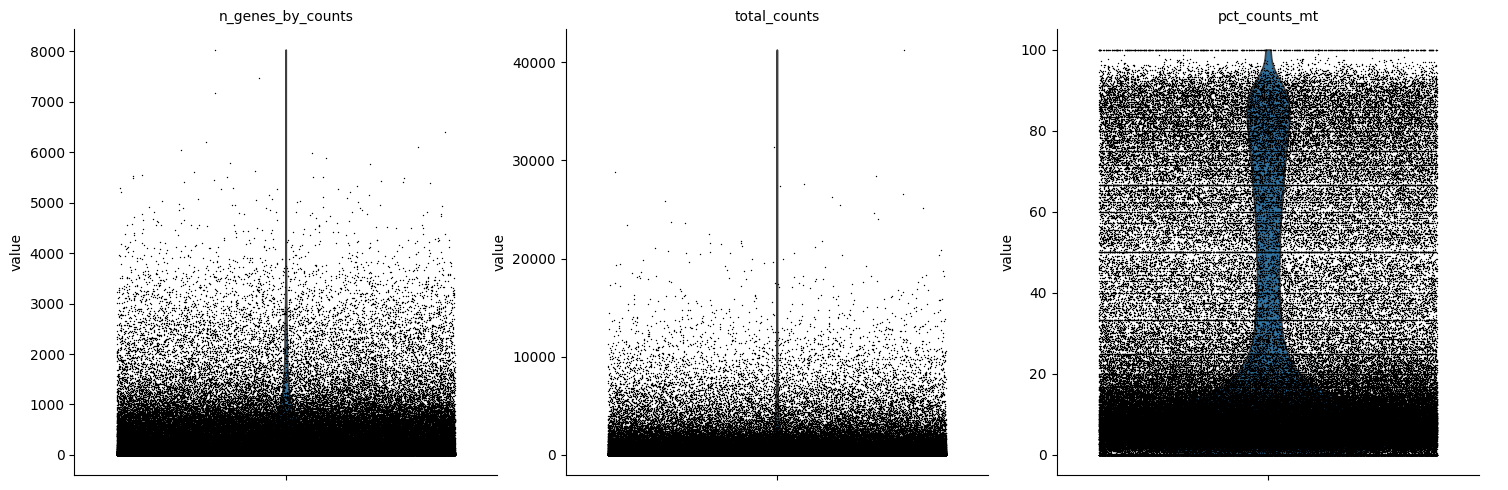

In [4]:
import scanpy as sc
adata = sc.read_h5ad(H5AD_PATH)
print(adata)

# # QC 지표 계산
adata.var['mt']   = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))
adata.var['hb']   = adata.var_names.str.contains(r'^HB[ABDEGMQZ]\d*(?!\w)')

sc.pp.calculate_qc_metrics(
    adata, qc_vars=['mt', 'ribo', 'hb'],
    percent_top=None, log1p=True, inplace=True
)

# Hard-cutoff 기준
print(adata.obs['n_genes_by_counts'].describe())
print(adata.obs['total_counts'].describe())

# QC 전 분포 확인
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, show=True)

### QC 그래프 확인

**그래프 해석**
1. n_genes_by_counts
    
    : 대부분의 세포가 0-2000 값에서 형성 되어있으나 일부 값이 8000까지 튀어있는 것을 보아 위로 튄 값은 doublet 의심
    
2. total_counts
    
    : 대부분 낮은 count값을 가지고 있는데 일부 세포가 40000까지 튀어있는 것을 보아 위로 튄 값은 비정상 의심
    
3. pct_counts_mt
    
    : 정상이면 20% 이하여야 하는데 100까지 퍼져 있는 것을 보아 죽은 세포가 많은 것으로 보임

**Hard cutoff 기준 근거**
하드 컷오프 적용 전 전체 데이터 분포:
| 지표 | 25th percentile | 50th percentile | mean |
|------|----------------|----------------|------|
| n_genes_by_counts | 22 | 71 | 308 |
| total_counts | 41 | 125 | 711 |

25th percentile이 각각 22, 41에 불과할 정도로 low-count 세포가 다수를 차지하고 있었다.
이 상태에서 MAD를 적용하면 중앙값(71, 125)이 낮게 형성되어 low-count 세포도 정상으로 판정된다.

`n_genes_by_counts ≥ 200`: 정상 세포는 최소 수백 개 유전자를 동시에 발현한다.
200 미만은 세포막이 파괴되어 mRNA가 유출된 사멸 세포로 판단한다.
Seurat, Scanpy 공식 튜토리얼에서도 200을 하한선으로 사용한다.

`total_counts ≥ 500`: 신뢰할 수 있는 유전자 발현 정보를 얻으려면 최소한의 sequencing depth가 필요하다.
중앙값이 125에 불과한 상황에서 500은 노이즈 세포를 걸러내는 보수적인 기준이다.

Hard cutoff: 173,954 -> 49,921 cells
MAD outlier:  135 cells flagged
MT outlier:   4,941 cells flagged
After MAD filter: 49,921 -> 44,860 cells


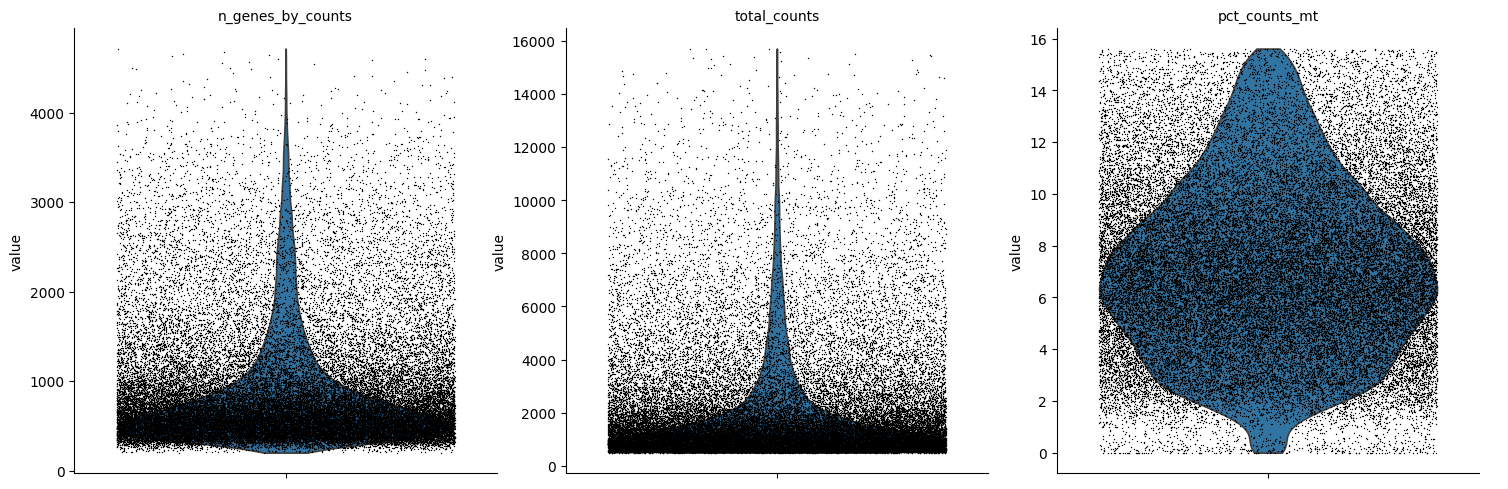

In [5]:
# Step 1: Hard cutoff (MAD 정상 작동을 위한 선처리)
n_before = adata.n_obs
adata = adata[adata.obs['n_genes_by_counts'] >= 200].copy()
adata = adata[adata.obs['total_counts'] >= 500].copy()
print(f"Hard cutoff: {n_before:,} -> {adata.n_obs:,} cells")

# Step 2: MAD-based outlier filter
def is_outlier(adata, metric: str, nmads: int) -> pd.Series:
    """중앙값 += (nmads × MAD) 범위를 벗어난 세포를 True로 반환"""
    M = adata.obs[metric]
    return (M < np.median(M) - nmads * median_abs_deviation(M)) | (np.median(M) + nmads * median_abs_deviation(M) < M)

adata.obs['outlier']    = (is_outlier(adata, 'log1p_total_counts', 5) |
                           is_outlier(adata, 'log1p_n_genes_by_counts', 5))
adata.obs['mt_outlier'] = (is_outlier(adata, 'pct_counts_mt', 3) |
                           (adata.obs['pct_counts_mt'] > 20))

print(f"MAD outlier:  {adata.obs['outlier'].sum():,} cells flagged")
print(f"MT outlier:   {adata.obs['mt_outlier'].sum():,} cells flagged")

n_before = adata.n_obs
adata = adata[(~adata.obs['outlier']) & (~adata.obs['mt_outlier'])].copy()
print(f"After MAD filter: {n_before:,} -> {adata.n_obs:,} cells")

# QC 후 분포 확인
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, show=True)

### Checkpoint 2 - QC 후 데이터 품질 검증

QC는 “세포를 줄이는 작업”이므로, 단순히 실행 여부보다 **몇 개가 제거되었고 어떤 기준으로 남았는지**를 확인해야 한다.

특히 normalization 전에 `total_counts = 0` 세포가 남아 있으면 `normalize_total`에서 경고가 날 수 있다.

In [6]:
ph1_report_adata_state(adata, "After QC")

qc_summary = adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe()
display(qc_summary)

print("\nRemaining zero-count cells:", int((adata.obs['total_counts'] == 0).sum()))
print("\nOutlier flags:")
print(adata.obs[['outlier', 'mt_outlier']].value_counts())


===== After QC =====
shape: 44,860 cells × 41,861 genes
X type: <class 'scipy.sparse._csr.csr_matrix'>
X dtype: float32
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'] ...
var columns: ['mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']
obsm keys: []
obsp keys: []
layers keys: []
uns keys: []


,n_genes_by_counts,total_counts,pct_counts_mt
count,44860.000000,44860.000000,44860.000000
mean,908.818012,2103.447998,7.061675
std,677.655421,2127.290283,3.363511
min,200.000000,500.000000,0.000000
25%,475.000000,845.000000,4.523809
50%,663.000000,1278.000000,6.799211
75%,1056.000000,2379.250000,9.293315
max,4714.000000,15699.000000,15.609756



Remaining zero-count cells: 0

Outlier flags:
outlier  mt_outlier
False    False         44860
Name: count, dtype: int64


## 3. Normalization

세포마다 sequencing depth가 다르므로 모든 세포를 동일한 기준(10,000 CPM)으로 맞춘 뒤  
`log1p` 변환으로 극단값을 압축한다. (`log1p`: count=0인 세포의 log(0) -> -∞ 방지)

raw count는 `adata.layers['counts']`에 보존 -> 이후 DEG 분석에서 활용

`target_sum=1e4 (10,000)` 으로 설정한 이유:
bulk RNA-seq의 CPM(Counts Per Million)에서 착안한 방식이다.
단, scRNA-seq는 세포당 포착되는 mRNA 수가 bulk 대비 훨씬 적기 때문에
1,000,000 대신 10,000을 기준값으로 사용하는 것이 scRNA-seq 분야의 관례다.
Seurat, Scanpy 공식 튜토리얼 모두 동일한 값을 사용한다.

In [7]:
# 0-count 세포 제거 (normalize_total의 0 나누기 방지용 방어 로직)
sc.pp.filter_cells(adata, min_counts=1)

# raw count 보존
adata.layers['counts'] = adata.X.copy()

# CPM normalization + log1p
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print(adata)

AnnData object with n_obs × n_vars = 44860 × 41861
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p'
    layers: 'counts'


### Checkpoint 3 - Normalization 결과 검증

`normalize_total()`은 세포 간 library size 차이를 보정하고, `log1p()`는 극단적으로 치우친 count 분포를 압축한다.

이 단계에서 중요한 점은 raw count를 잃지 않는 것이다.  
그래서 normalization 직전에 `adata.layers['counts']`에 원본 count matrix를 보존한다.

In [8]:
ph1_report_adata_state(adata, "After normalization")

print("\nRaw count layer exists:", 'counts' in adata.layers)
print("log1p metadata:", adata.uns.get('log1p', 'not found'))

# log1p 이후 값 범위 확인
if hasattr(adata.X, "data"):
    print("X non-zero min/max after log1p:", float(adata.X.data.min()), float(adata.X.data.max()))
else:
    print("X min/max after log1p:", float(np.min(adata.X)), float(np.max(adata.X)))


===== After normalization =====
shape: 44,860 cells × 41,861 genes
X type: <class 'scipy.sparse._csr.csr_matrix'>
X dtype: float32
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'] ...
var columns: ['mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']
obsm keys: []
obsp keys: []
layers keys: ['counts']
uns keys: ['log1p']

Raw count layer exists: True
log1p metadata: {'base': None}
X non-zero min/max after log1p: 0.492855042219162 8.966066360473633


## 4. Highly Variable Gene (HVG) Selection

41,861개 유전자 중 **세포마다 발현 차이가 큰 상위 2,000개**만 선택한다.  
모든 세포에서 균일하게 발현되는 유전자는 세포 타입 구분에 기여하지 않으므로 제거한다.

`n_top_genes=2000`: Seurat/Scanpy 공식 기본값. 너무 적으면 정보 손실, 너무 많으면 노이즈 증가.  
`flavor='seurat_v3'`: raw count 기반 분산 추정 -> `layer='counts'` 지정 필요

HVG: 2,000 / 41,861 genes selected


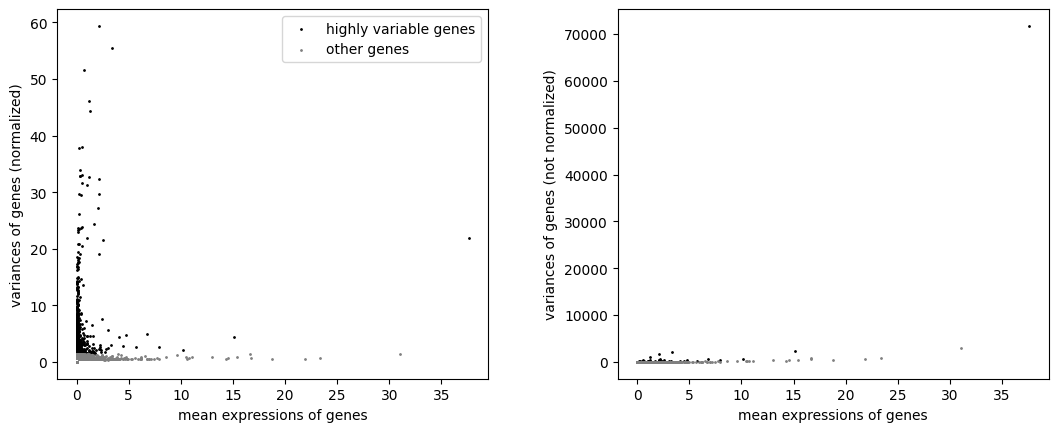

After HVG filter: (44860, 2000)


In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000,
                            flavor='seurat_v3', layer='counts')
print(f"HVG: {adata.var.highly_variable.sum():,} / {adata.n_vars:,} genes selected")
sc.pl.highly_variable_genes(adata)

# annotation 시 HVG 외 marker gene 조회를 위해 전체 유전자 백업
adata.raw = adata

# HVG만 남기기
adata = adata[:, adata.var.highly_variable].copy()
print(f"After HVG filter: {adata.shape}")

### Checkpoint 4 - HVG 및 raw backup 검증

HVG 필터 후 `adata.X`에는 2,000개 유전자만 남는다.  
하지만 annotation에서는 HVG에 포함되지 않은 marker gene도 확인해야 하므로, 필터링 직전 `adata.raw`에 전체 유전자를 백업한다.

In [10]:
ph1_report_adata_state(adata, "After HVG filter")

print("\nadata.raw exists:", adata.raw is not None)
if adata.raw is not None:
    print("adata.raw shape:", adata.raw.shape)
    marker_check = ['CD3D', 'CD68', 'EPCAM', 'CD19']
    print("\nMarker availability")
    for g in marker_check:
        print(f"{g:>6} | in adata.var_names: {g in adata.var_names} | in adata.raw.var_names: {g in adata.raw.var_names}")


===== After HVG filter =====
shape: 44,860 cells × 2,000 genes
X type: <class 'scipy.sparse._csr.csr_matrix'>
X dtype: float32
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'] ...
var columns: ['mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means'] ...
obsm keys: []
obsp keys: []
layers keys: ['counts']
uns keys: ['log1p', 'hvg']

adata.raw exists: True
adata.raw shape: (44860, 41861)

Marker availability
  CD3D | in adata.var_names: False | in adata.raw.var_names: True
  CD68 | in adata.var_names: True | in adata.raw.var_names: True
 EPCAM | in adata.var_names: True | in adata.raw.var_

-> 왼쪽 그래프(normalized)에서 분산 높은 유전자군이 상단에 명확하게 분리되어 있어 2,000개 선택이 이 데이터에서도 유효함을 시각적으로 확인할 수 있다

## 5. PCA

2,000개 유전자 공간을 50개의 주성분(PC)으로 압축한다.  
`pca_variance_ratio` 플롯에서 elbow 지점(분산 기여도가 급감하는 지점)까지의 PC 수를  
Harmony -> UMAP의 `n_pcs`로 사용한다.

`svd_solver='arpack'`: 대용량 sparse matrix에 최적화된 방식 (iterative partial SVD)

c:\Users\82108\anaconda3\envs\spatial\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


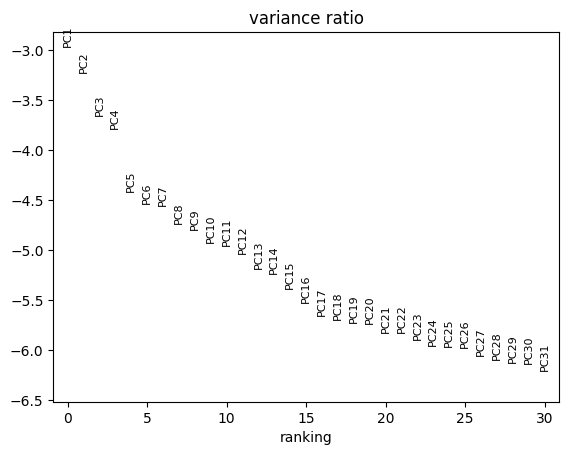

In [11]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)
# -> elbow 확인 후 아래 n_pcs 결정 (본 데이터: PC17 이후 완만 -> n_pcs=17)

In [ ]:
vr_full = adata.uns['pca']['variance_ratio']
diffs_full = np.diff(vr_full)
for i, d in enumerate(diffs_full[:30], start=1):
    print(f'PC{i} -> PC{i+1}: {d:.5f}')

### Checkpoint 5 - PCA 결과 검증

PCA 이후 각 세포는 `adata.obsm['X_pca']`에 저장된 PC 좌표를 가진다.  
이 좌표는 이후 Harmony, neighbors graph, UMAP, Leiden의 입력으로 사용된다.

In [12]:
ph1_report_adata_state(adata, "After PCA")

print("X_pca shape:", adata.obsm['X_pca'].shape)
print("\nExplained variance ratio first 20 PCs:")
print(np.round(adata.uns['pca']['variance_ratio'][:20], 5))


===== After PCA =====
shape: 44,860 cells × 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'] ...
var columns: ['mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means'] ...
obsm keys: ['X_pca']
obsp keys: []
layers keys: ['counts']
uns keys: ['log1p', 'hvg', 'pca']
X_pca shape: (44860, 50)

Explained variance ratio first 20 PCs:
[0.0513  0.03952 0.02588 0.02259 0.01204 0.01064 0.01048 0.00873 0.00828
 0.00725 0.007   0.00651 0.0056  0.00531 0.00456 0.00398 0.00351 0.00334
 0.00326 0.00321]


## 6. Batch Correction (Harmony)

26개 샘플은 서로 다른 환자·시점에서 수집되어 **batch effect** 가 존재한다.  
batch effect 방치 시 생물학적 유사성이 아닌 샘플 출처로 클러스터가 형성된다.

Harmony는 PCA 임베딩을 샘플별로 반복 보정하여 sample-agnostic한 표현을 생성한다.  
보정 결과는 `adata.obsm['X_pca_harmony']`에 저장된다.

In [13]:
# 샘플 정보 추출 (barcode 접미사에 샘플 번호가 인코딩됨: 'bcXXXX-2' -> sample='2')
adata.obs['sample'] = adata.obs_names.str.split('-').str[-1]
print(adata.obs['sample'].value_counts())

# Harmony batch correction
pca_result = adata.obsm['X_pca']
meta = adata.obs[['sample']]
ho = hm.run_harmony(pca_result, meta, 'sample')

# harmonypy의 Z_corr는 버전에 따라 (n_pcs, n_cells) 형태로 반환될 수 있으므로 shape 검증 후 저장
Z_corr = ho.Z_corr
if Z_corr.shape[0] != adata.n_obs and Z_corr.shape[1] == adata.n_obs:
    Z_corr = Z_corr.T

assert Z_corr.shape[0] == adata.n_obs, f"Unexpected Harmony shape: {Z_corr.shape}"
adata.obsm['X_pca_harmony'] = Z_corr

print("Harmony done.")
print("X_pca:", adata.obsm['X_pca'].shape)
print("X_pca_harmony:", adata.obsm['X_pca_harmony'].shape)

2026-06-03 17:18:19,020 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-06-03 17:18:19,020 - harmonypy - INFO -   Parameters:
2026-06-03 17:18:19,021 - harmonypy - INFO -     max_iter_harmony: 10
2026-06-03 17:18:19,022 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-03 17:18:19,022 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-03 17:18:19,022 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-03 17:18:19,023 - harmonypy - INFO -     nclust: 100
2026-06-03 17:18:19,024 - harmonypy - INFO -     block_size: 0.05
2026-06-03 17:18:19,025 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
2026-06-03 17:18:19,025 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2.]
2026-06-03 17:18:19,026 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-03 17:18:19,027 - harmonypy - INFO -     verbose: True
2026-06-03 17:18:19,027 - harmonyp

sample
9     3752
11    2863
12    2839
10    2667
23    2555
20    2365
1     2330
6     2295
24    2275
5     2214
21    2161
0     2110
19    2057
4     1741
16    1575
14    1396
3     1361
15    1295
18    1216
2     1170
13     983
25     600
17     386
22     289
7      194
8      171
Name: count, dtype: int64


2026-06-03 17:18:19,295 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
2026-06-03 17:18:21,328 - harmonypy - INFO - KMeans initialization complete.
2026-06-03 17:18:21,589 - harmonypy - INFO - Iteration 1 of 10
2026-06-03 17:18:22,775 - harmonypy - INFO - Iteration 2 of 10
2026-06-03 17:18:23,780 - harmonypy - INFO - Iteration 3 of 10
2026-06-03 17:18:24,730 - harmonypy - INFO - Iteration 4 of 10
2026-06-03 17:18:25,743 - harmony

Harmony done.
X_pca: (44860, 50)
X_pca_harmony: (44860, 50)


### Checkpoint 6 - Harmony 결과 검증

Harmony 결과는 `adata.obsm['X_pca_harmony']`에 저장된다.  
이 shape가 `(세포 수, PC 수)`가 아니면 이후 neighbors/UMAP에서 잘못된 입력을 쓰게 된다.

In [14]:
ph1_report_adata_state(adata, "After Harmony")

print("X_pca_harmony shape:", adata.obsm['X_pca_harmony'].shape)
print("sample count:", adata.obs['sample'].nunique())


===== After Harmony =====
shape: 44,860 cells × 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'] ...
var columns: ['mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means'] ...
obsm keys: ['X_pca', 'X_pca_harmony']
obsp keys: []
layers keys: ['counts']
uns keys: ['log1p', 'hvg', 'pca']
X_pca_harmony shape: (44860, 50)
sample count: 26


## 7. UMAP + Leiden Clustering

**UMAP**: Harmony로 보정된 임베딩을 2D로 펼쳐 시각화한다. 비슷한 유전자 발현 패턴의 세포가 근접 배치된다.  
**Leiden**: graph 기반 클러스터링 알고리즘. `resolution`으로 클러스터 세분화 정도 조절.  
`random_state=42`로 UMAP 재현성 고정.

`n_pcs=17`: PCA elbow plot 기준

c:\Users\82108\anaconda3\envs\spatial\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\82108\AppData\Local\Temp\ipykernel_28200\842202856.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, random_state=42)


Clusters: 15


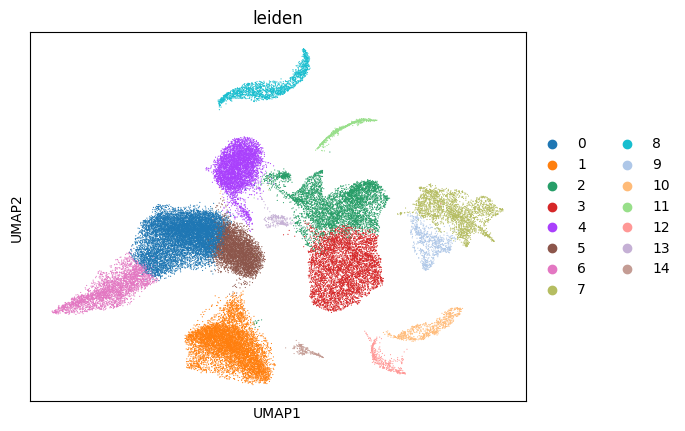

In [15]:
N_PCS = 17  # PCA variance ratio elbow 기준

sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_pcs=N_PCS, random_state=42)
sc.tl.umap(adata, random_state=42)
sc.tl.leiden(adata, resolution=0.5, random_state=42)

print(f"Clusters: {adata.obs['leiden'].nunique()}")
sc.pl.umap(adata, color=['leiden'])

### Checkpoint 7 - Neighbors graph / UMAP / Leiden 검증

`sc.pp.neighbors()`는 시각화가 아니라 세포 간 관계망을 `adata.obsp`와 `adata.uns['neighbors']`에 저장한다.  
UMAP과 Leiden은 이 graph를 기반으로 각각 2D 시각화와 cluster label을 만든다.

따라서 이 단계에서는 graph key, UMAP 좌표, cluster 분포를 함께 확인한다.

In [16]:
ph1_report_adata_state(adata, "After UMAP + Leiden")

print("\nNeighbor graph keys:", list(adata.obsp.keys()))
print("UMAP shape:", adata.obsm['X_umap'].shape)
print("Cluster count:", adata.obs['leiden'].nunique())

cluster_counts = adata.obs['leiden'].value_counts().sort_index()
display(cluster_counts.to_frame("n_cells"))

print("\nTop 10 largest clusters:")
display(adata.obs['leiden'].value_counts().head(10).to_frame("n_cells"))


===== After UMAP + Leiden =====
shape: 44,860 cells × 2,000 genes
X type: <class 'numpy.ndarray'>
X dtype: float64
obs names unique: True
var names unique: True
obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb'] ...
var columns: ['mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means'] ...
obsm keys: ['X_pca', 'X_pca_harmony', 'X_umap']
obsp keys: ['distances', 'connectivities']
layers keys: ['counts']
uns keys: ['log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors']

Neighbor graph keys: ['distances', 'connectivities']
UMAP shape: (44860, 2)
Cluster count: 15


,n_cells
leiden,
0,9665
1,6956
2,4792
3,4775
4,4572
5,4282
6,3040
7,2308
8,1641



Top 10 largest clusters:


,n_cells
leiden,
0,9665
1,6956
2,4792
3,4775
4,4572
5,4282
6,3040
7,2308
8,1641


## 8. Cell Type Annotation

알려진 marker gene 발현량을 UMAP에 overlay하여 각 클러스터의 세포 타입을 확인한다.  
`adata.raw`에 백업된 전체 유전자에서 marker를 조회하므로 HVG에 없는 유전자도 확인 가능.

| Marker | Cell type |
|--------|-----------|
| CD3D   | T cell    |
| CD68   | Macrophage |
| EPCAM  | Cancer cell (epithelial) |
| CD19   | B cell    |

발현량이 주변보다 명확히 높은(청록색 이상) 클러스터만 해당 세포 타입으로 지정.
발현이 절반 이하이거나 애매한 클러스터는 Unknown으로 보류 -> Phase 2에서 세분화 예정.

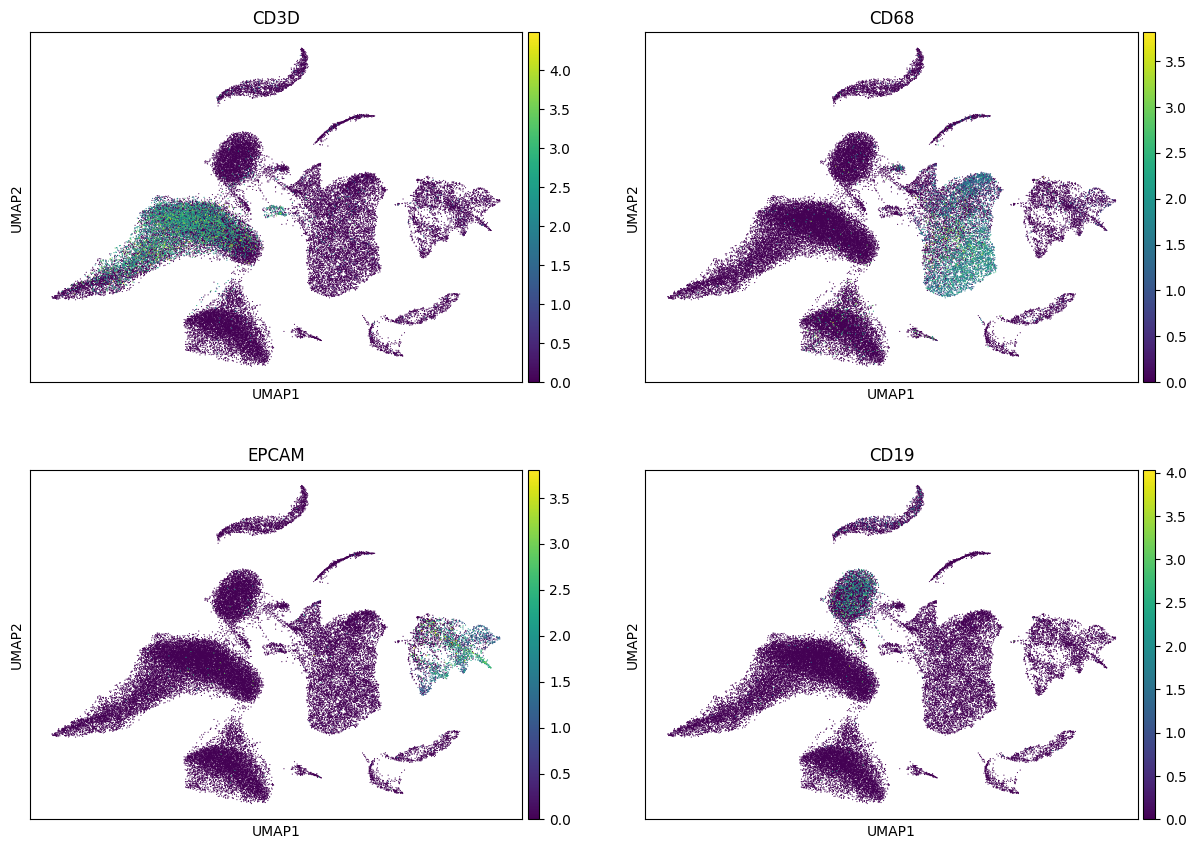

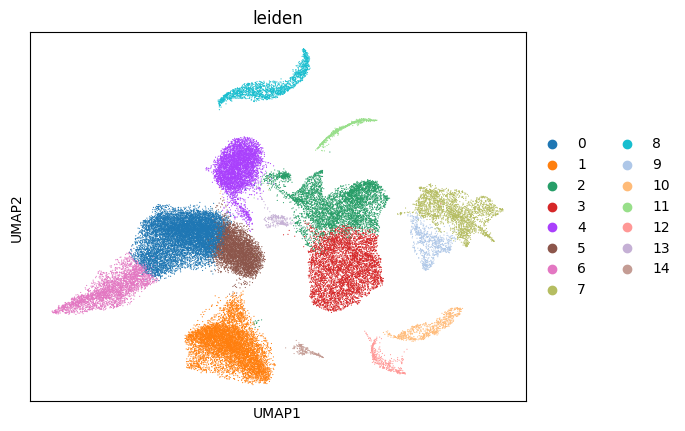

In [17]:
# Marker gene 발현량 확인
sc.pl.umap(adata, color=['CD3D', 'CD68', 'EPCAM', 'CD19'], ncols=2, use_raw=True)
sc.pl.umap(adata, color='leiden')

cell_type
Unknown        14937
T cell         12705
Macrophage      9567
B cell          4572
Cancer cell     3079
Name: count, dtype: int64


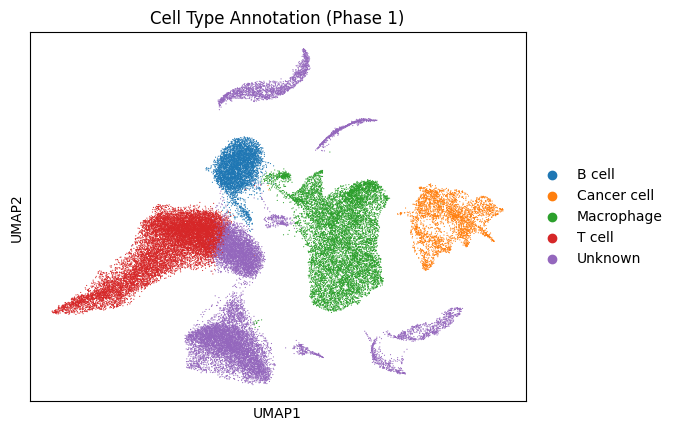

In [27]:
# 클러스터 -> 세포 타입 매핑
# Unknown: 단일 marker로 판단이 불명확한 클러스터 (Phase 2에서 세분화 예정)
cell_type_map = {
    '0': 'T cell',
    '6': 'T cell',
    '2': 'Macrophage',
    '3': 'Macrophage',
    '4': 'B cell',
    '7': 'Cancer cell',
    '9': 'Cancer cell',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map).fillna('Unknown')

print(adata.obs['cell_type'].value_counts())
sc.pl.umap(adata, color='cell_type', title='Cell Type Annotation (Phase 1)')

### Checkpoint 8 - Annotation 결과 검증

Annotation은 자동 정답이 아니라 marker gene 기반 해석이므로,  
최종적으로 cell type별 세포 수와 Unknown 비율을 확인한다.

In [30]:
annotation_summary = adata.obs['cell_type'].value_counts().to_frame("n_cells")
annotation_summary["ratio"] = annotation_summary["n_cells"] / adata.n_obs
display(annotation_summary)

print(f"Unknown ratio: {annotation_summary.loc['Unknown', 'ratio']:.2%}" if 'Unknown' in annotation_summary.index else "No Unknown cells")

,n_cells,ratio
cell_type,,
Unknown,14937,0.332969
T cell,12705,0.283214
Macrophage,9567,0.213263
B cell,4572,0.101917
Cancer cell,3079,0.068636


Unknown ratio: 33.30%


In [31]:
adata.write_h5ad(HUMAN_H5AD)
print(f"Saved -> {HUMAN_H5AD}")
print(adata)

Saved -> dataset\GSE127465_human_final.h5ad
AnnData object with n_obs × n_vars = 44860 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_counts', 'sample', 'leiden', 'cell_type'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
